In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
# Heart Disease Prediction using Machine Learning

## Objective
## The goal of this project is to build a machine learning model that predicts whether a patient has heart disease based on clinical features. Two classification algorithms, Logistic Regression and Decision Tree, are trained and evaluated using the Heart Disease dataset.

In [ ]:
from google.colab import files

files.upload()

Saving archive (2).zip to archive (2) (1).zip


{'archive (2) (1).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00C\tYO\x95\xf1?\xf0\xff\xff\xff\xff\xff\xff\xff\xff\t\x00\x14\x00heart.csv\x01\x00\x10\x00\xe2\x94\x00\x00\x00\x00\x00\x00\x19\x18\x00\x00\x00\x00\x00\x00\xad]\xd9\x8e$\xb9\x91|\x17\xd0\x7f\x12H\xf0\x8a\xc8\x88\xcfi\xcd\xf6\xce\x00;\xd0\x0c\xd4\xfd\xa0\xcf\xdf\xa0\xbb\x19\xc9\xcc\xaa`X\x01\xc2@\xea\xec.\x16\x0f?\xcd\x0f2\xbf\xff\xfec\xf9\xf9\xe3?\xcbo\x7f/\xbf\xfe\xfd\xe3\xe7\xaf\x7f\xfe\xfds\xf9\xed\x8f\xbf\xfe\\\xfe\xf7\x9f?\x97\xfa\x0f?~\xfb}\xf9\xf5\xc7\xf7?\xbf\xff\xf6\xc7\xf2\xe3?\xdf\xff\xf5\xfb\xf2\xd7\x9f\xff\xf3\xf7\x8f\xef\xff\xb7\xfc\xfc\xf3\xaf\xbf\x7f,\xbf}\xb7\x1f/\xbf\xbe\xff\xfb\xf7\x1f\xbf\xbe\xfdcMK\\\xc2\x12\xd3\xba\xa4\x98\xea\xa7%n\xbb\xfd\x99\xce\xff\xf2\x12\xce1\xd9\xc7\x94\xb0\xa4\x80\xcf\xebz\xfe\x99\x1f\xf5s\xf0Q\xcf\x80Q\xe7O\x9e\xc5gJuTzl}\xd4\x161j\xb7\xb9|=\x9f\xa5\xee\xc4\xc7$\xfb{\xcc\xe7\x98\xa3\xd4\x11K\x0cu\x8e\xf88lL\xb2]\xed>*\x9c\xbfY\xf09\xe1\x04>\x9b\x8d\xb1\xd5bYr\xdc\xfd_K\x1dY\x1e\xc5v\x

In [ ]:
!unzip 'archive (2).zip'

Archive:  archive (2).zip
replace heart.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: heart.csv               


In [ ]:
## Dataset Loading

## The dataset is loaded using the pandas library. We inspect the first few rows and the structure of the dataset to understand the available features and the target variable.

In [ ]:
import pandas as pd

df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
## Exploratory Data Analysis

## EDA helps us understand the data before model training. In this section, we check for missing values, duplicate records, feature distributions, and relationships between variables.

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(723)

In [ ]:
df = df.drop_duplicates()

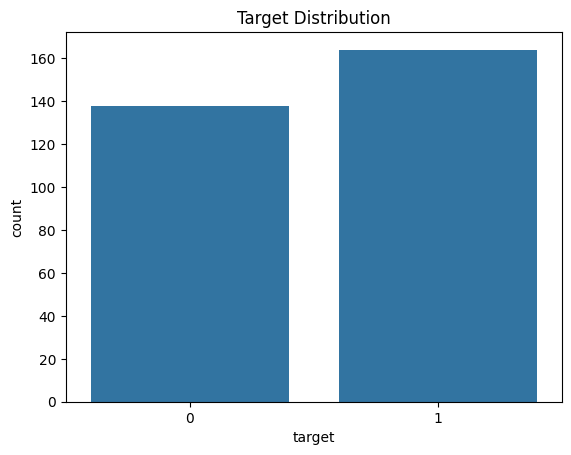

In [ ]:
sns.countplot(x='target', data=df)

plt.title("Target Distribution")
plt.show()

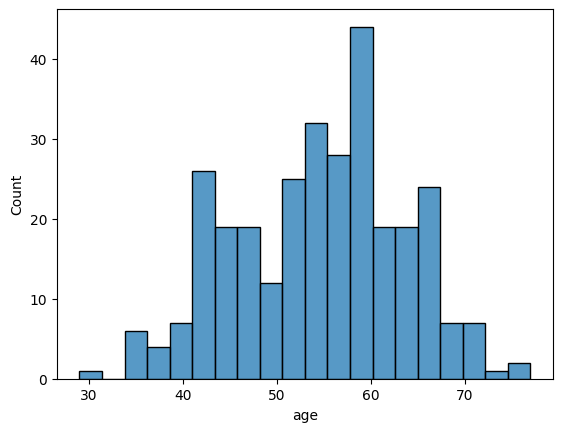

In [ ]:
sns.histplot(df['age'], bins=20)
plt.show()

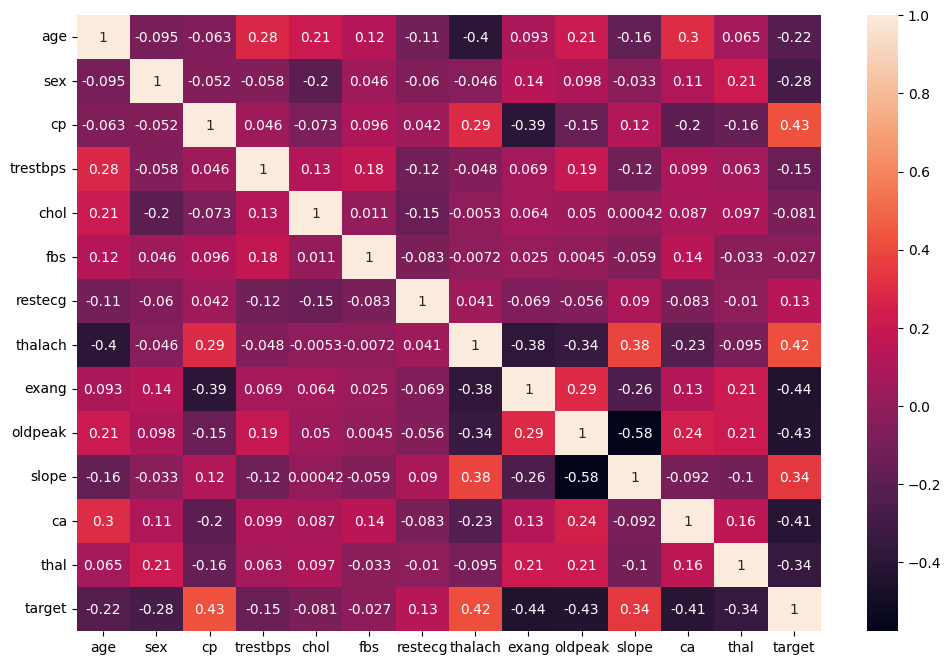

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True)

plt.show()

In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

In [ ]:
## Data Preprocessing

## The features are separated from the target variable, and the data is split into training and testing sets using an 80:20 ratio. StandardScaler is applied before Logistic Regression because it performs better when numerical features are on a similar scale.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
## LOGISTIC REGRESSION
## Logistic regression separates data into classes by learning a decision boundary, and then like define them in clusters and train the model(supervised learning) and labeled training data  is used to learn the probability that a data point belongs to which particular class

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.7704918032786885


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61



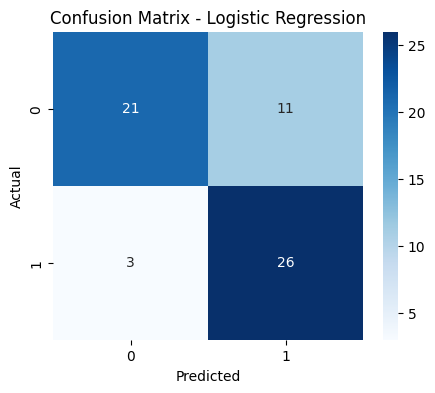

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
## Decision Tree Classifier

## Decision Tree is another supervised learning algorithm that classifies data by learning decision rules from the training data. Unlike Logistic Regression, it does not require feature scaling.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7377049180327869
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



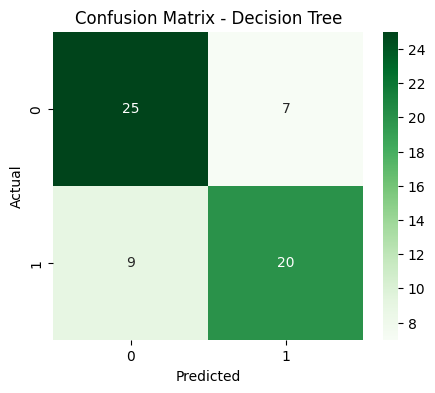

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [ ]:
## Model Comparison and Conclusion

## Both models were evaluated on the test dataset. Logistic Regression achieved better generalization performance than the Decision Tree model on this dataset. Based on the evaluation metrics, Logistic Regression is selected as the preferred model for heart disease prediction.
## The reasons could be:
## 1. The dataset is relatively small (about 300 samples).
## 2. The relationship between features and the target is often close to linear.
## 3. Logistic Regression is less prone to overfitting.